# Preprocessing et entraînement (Deep Learning - LSTM)
*(Génération de **programmes sportifs**)*

- **Dataset Kaggle** :  
  [600K+ Fitness Exercise & Workout Program Dataset – Kaggle](https://www.kaggle.com/datasets/adnanelouardi/600k-fitness-exercise-and-workout-program-dataset)

## Imports

In [ ]:
# Bibliothèques principales
import re
from pathlib import Path
import sys
import platform
import random
from pathlib import Path
import json
from datetime import datetime
import warnings
from collections import Counter
import random

# Imports Python / data science classiques
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
import kagglehub
from itables import show


# PyTorch & HuggingFace (version Transformers)
import torch
import torch.nn as nn
from torch.utils.data import  DataLoader
import transformers

Ajouté au PYTHONPATH : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks
Contenu de c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks : ['dataset_fusion', 'eda', 'model_training', 'preprocessing', 'themes', '__init__.py', '__pycache__']


## Configuration

### Configuration GPU

In [77]:
warnings.filterwarnings("ignore")

# Infos système
print("TrAIn.me — Environnement Windows (PyTorch / Transformers)\n")
print(f"Système      : {platform.system()} {platform.release()}")
print(f"Architecture : {platform.machine()}")

# GPU / CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"\nGPU détecté : {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("\nAucun GPU CUDA détecté — utilisation du CPU (plus lent)")

TrAIn.me — Environnement Windows (PyTorch / Transformers)

Système      : Windows 10
Architecture : AMD64

Aucun GPU CUDA détecté — utilisation du CPU (plus lent)


### Configuration graphiques

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

root = Path.cwd()
themes_root = None

for p in [root, *root.parents]:
    if (p / "themes").is_dir():
        themes_root = p
        break

if themes_root is None:
    raise FileNotFoundError(
        f"Impossible de trouver le dossier 'themes' en partant de {root}. "
    )

if str(themes_root) not in sys.path:
    sys.path.insert(0, str(themes_root))

print("Ajouté au PYTHONPATH :", themes_root)
print("Contenu de", themes_root, ":", [x.name for x in (themes_root).iterdir()])

# Thème personnalisé du projet (uniquement pour les notebooks)
from themes.theme_train_me import set_trainme_theme

# Appliquer le thème graphique TrAIn.me
set_trainme_theme()

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Le notebook s’exécute depuis son répertoire → on peut repartir du cwd
current_dir = Path.cwd()
project_root = current_dir.parents[3]  # remonte jusqu’à "train.me"

# Thème TrAIn.me (Seaborn/Matplotlib)=
palette_trainme = set_trainme_theme(context="talk", font_scale=1.05, use_dark=True)
palette_trainme

['#00E5FF', '#00BFFF', '#0A84FF', '#1E90FF', '#00FFFF', '#64D8FF']

### Header expérimental

In [79]:
# Reproductibilité complète
SEED_GLOBAL = 42
random.seed(SEED_GLOBAL)
np.random.seed(SEED_GLOBAL)
torch.manual_seed(SEED_GLOBAL)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED_GLOBAL)

OUTPUT_MODEL_NAME = "lstm_v5"

SEED_GEN = 123 

EPOCHS = 150
BATCH_SIZE = 32
MAX_SEQUENCE_LENGTH = 150
EMBED_DIM = 32
LSTM_UNITS = 128

# Hyperparamètres du modèle
EMBEDDING_DIM = EMBED_DIM
LSTM_UNITS     = LSTM_UNITS
NUM_LAYERS     = 2
DROPOUT        = 0.2

### Affichage des versions d'imports

In [80]:
print("\nVersions utilisées :")
print(f"  - torch        : {torch.__version__}")
print(f"  - transformers : {transformers.__version__}")
print("  - datasets     : installé (HuggingFace Datasets)")
print("\nEnvironnement configuré")


Versions utilisées :
  - torch        : 2.9.1+cpu
  - transformers : 4.57.3
  - datasets     : installé (HuggingFace Datasets)

Environnement configuré


## Chargement et préparation du corpus TrAIn.me


### Concaténation du texte

In [ ]:
print("Chargement du corpus TrAIn.me (program_summary.csv)...\n")

# Téléchargement automatique du dataset Kaggle
path = kagglehub.dataset_download(
    "adnanelouardi/600k-fitness-exercise-and-workout-program-dataset"
)

print("Dataset téléchargé avec succès !")
print("Chemin local :", path, "\n")

# Conversion du chemin KaggleHub → Path
dataset_dir = Path(path)

# Fichier CSV principal (structure confirmée dans le dataset Kaggle)
csv_path = dataset_dir / "program_summary.csv"

print(f"Lecture du fichier : {csv_path.name}\n")

# Chargement du corpus fusionné
df = pd.read_csv(csv_path)

print("Corpus chargé avec succès !\n")
print("Aperçu du corpus :")
print(df.head())

print("\nInformations générales :")
print(f"  - Nombre total d’entrées : {len(df)}")
print(f"  - Colonnes disponibles    : {list(df.columns)}")

# Sélection des colonnes textuelles à utiliser pour le LSTM
candidate_text_cols = ["text", "program_text", "description", "exercises", "notes"]
text_columns = [c for c in candidate_text_cols if c in df.columns]

if not text_columns:
    # fallback : toutes les colonnes de type "object" (texte)
    text_columns = [c for c in df.columns if df[c].dtype == "object"]

print("\nColonnes textuelles utilisées pour construire le corpus :")
print(f"  - {text_columns}")

# Construction d'une liste de textes à partir des colonnes retenues
corpus_texts = []
for _, row in df[text_columns].iterrows():
    # On concatène les différentes colonnes textuelles ligne par ligne
    parts = [str(v).strip() for v in row.values if isinstance(v, str) and v.strip()]
    if parts:
        corpus_texts.append("\n".join(parts))

print(f"\nNombre de segments textuels retenus : {len(corpus_texts)}")

# Concaténation globale pour le POC LSTM (équivalent à l'ancien full_text)
full_text = "\n\n".join(t.strip() for t in corpus_texts if t and isinstance(t, str))

print("\nRésumé du corpus concaténé :")
print(f"  - Longueur totale (caractères) : {len(full_text)}")
print("  - Aperçu (500 premiers caractères) :\n")
print(full_text[:500])


Chargement du corpus TrAIn.me (program_summary.csv)...

Dataset téléchargé avec succès !
Chemin local : C:\Users\fback\.cache\kagglehub\datasets\adnanelouardi\600k-fitness-exercise-and-workout-program-dataset\versions\1 

Lecture du fichier : program_summary.csv

Corpus chargé avec succès !

Aperçu du corpus :
                                               title                                        description  \
0  (MASS MONSTER) High Intensity 4 Day Upper Lowe...  Build tones of muscular with this high intensi...   
1                         (NOT MY PROGRAM)SHJ Jotaro                            Build strength and size   
2  1 PowerLift Per Day Powerbuilding 5 Day Bro Split  Based off of Andy Baker's KCS (Kingwood Streng...   
3                      10 Week Mass Building Program  This workout is designed to increase your musc...   
4                             10 week deadlift focus                                  Increase deadlift   

                                    level    

### Vérifications du corpus

In [ ]:
print("\nVérifications du corpus LSTM TrAIn.me")

# Taille brute du texte
print(f"Longueur totale du corpus (caractères) : {len(full_text)}")

# Quelques statistiques simples
nb_lignes = full_text.count("\n")
nb_mots = len(full_text.split())

print(f"Nombre approximatif de lignes : {nb_lignes}")
print(f"Nombre approximatif de mots   : {nb_mots}")

# Aperçu du contenu
print("\nExemple brut du corpus (300 premiers caractères)\n")
print(full_text[:300])

# Vérification de segments aléatoires
print("\nExemples aléatoires du corpus\n")
for i in range(3):
    idx = random.randint(0, len(corpus_texts) - 1)
    extrait = corpus_texts[idx][:200].replace("\n", " ")
    print(f"[{i+1}] {extrait}...")



Vérifications du corpus LSTM TrAIn.me
Longueur totale du corpus (caractères) : 777003
Nombre approximatif de lignes : 13033
Nombre approximatif de mots   : 130585

Exemple brut du corpus (300 premiers caractères)

Build tones of muscular with this high intensity 4 day upper lower workout routine.

Weekly Setup:
Day 1 - Upper Push Focus
Day 2 - Lower Quad Focus
Day 3 - Rest/Active Recovery
Day 4 - Upper Pull Focus
Day 5 - Rest/Active Recovery
Day 6 - Lower Hamstring Focus
Day 7 - Rest/Active Recovery 

Muscle 

Exemples aléatoires du corpus

[1] Beginner friendly simple...
[2] Overload Overload is critical to the muscle building process. Push each set for the maximum number of reps, stopping that set either when you feel your form is slipping, or if you feel like you may fa...
[3] To push you to the limits and not hold back one bit...


### Prétraitement du texte

In [83]:
def clean_text(texte):
    """Nettoie et normalise le texte pour un modèle word-level PyTorch."""
    texte = texte.lower()

    # Retirer complètement les apostrophes (évite des tokens isolés)
    texte = texte.replace("'", "")

    # Ajouter un espace autour de la ponctuation utile
    texte = re.sub(r"([.,!?])", r" \1 ", texte)

    # Supprimer les espaces multiples
    texte = re.sub(r"\s+", " ", texte)

    return texte.strip()


# Nettoyer le corpus fusionné
full_text_clean = clean_text(full_text)

print("Longueur avant nettoyage :", len(full_text))
print("Longueur après nettoyage :", len(full_text_clean))

print("\nAperçu du texte nettoyé :")
print(full_text_clean[:500], "...")

Longueur avant nettoyage : 777003
Longueur après nettoyage : 782989

Aperçu du texte nettoyé :
build tones of muscular with this high intensity 4 day upper lower workout routine . weekly setup: day 1 - upper push focus day 2 - lower quad focus day 3 - rest/active recovery day 4 - upper pull focus day 5 - rest/active recovery day 6 - lower hamstring focus day 7 - rest/active recovery muscle groups |sets per week back - 10 shoulders - 10 chest - 9 quads - 9 hamstrings - 9 glutes - 9 biceps - 7 triceps - 7 lower back - 4 calves - 4 abs - 4 build strength and size based off of andy bakers kcs ...


### Tokenisation

In [84]:
# Découper le texte nettoyé en mots
tokens = full_text_clean.split()

# Construire les fréquences
counter = Counter(tokens)

# Ajouter un token <UNK> pour les mots hors vocabulaire
# Ajouter un token <PAD> pour le remplissage
special_tokens = ["<PAD>", "<UNK>"]

# Vocabulaire final : tokens spéciaux + tokens triés par fréquence
vocab = special_tokens + [word for word, _ in counter.most_common()]

# Dictionnaires d'encodage / décodage
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

vocab_size = len(vocab)

print(f"Taille du vocabulaire : {vocab_size} mots\n")
print("Top 20 mots les plus fréquents :\n")

for i, (word, freq) in enumerate(counter.most_common(20), 1):
    print(f"  {i:2d}. '{word}' : {freq} fois")

Taille du vocabulaire : 11080 mots

Top 20 mots les plus fréquents :

   1. '.' : 7435 fois
   2. ',' : 5851 fois
   3. 'the' : 4194 fois
   4. 'and' : 4017 fois
   5. 'to' : 3900 fois
   6. 'a' : 2702 fois
   7. 'for' : 2214 fois
   8. 'you' : 2006 fois
   9. 'of' : 1884 fois
  10. 'is' : 1681 fois
  11. 'program' : 1603 fois
  12. 'this' : 1443 fois
  13. 'on' : 1395 fois
  14. 'with' : 1293 fois
  15. 'in' : 1235 fois
  16. 'week' : 1193 fois
  17. 'strength' : 1020 fois
  18. 'your' : 998 fois
  19. 'muscle' : 797 fois
  20. 'day' : 787 fois


### Préparation des séquences d’entraînement

In [85]:
# Longueur fixe de la séquence (contexte)
SEQ_LEN = MAX_SEQUENCE_LENGTH

def prepare_sequences_wordlevel(text: str, word2idx: dict, seq_len: int):
    """Convertit le texte en une longue séquence d'indices,
    puis génère des séquences (contexte → mot suivant)."""
    
    # Conversion word → id avec fallback <UNK>
    tokens = [word2idx.get(w, word2idx["<UNK>"]) for w in text.split()]
    
    sequences = []
    for i in range(seq_len, len(tokens)):
        # Contexte = les seq_len derniers mots
        # Cible    = mot suivant
        seq = tokens[i-seq_len : i+1]   # fenêtre glissante
        sequences.append(seq)
    
    return sequences, tokens


# Création des séquences
sequences, all_tokens = prepare_sequences_wordlevel(
    text=full_text_clean,
    word2idx=word2idx,
    seq_len=SEQ_LEN
)

print(f"Nombre total de séquences : {len(sequences)}")

# Conversion en numpy array
sequences_array = np.array(sequences, dtype=np.int64)

# X = les seq_len premiers tokens (contexte)
# y = le token cible (indice entier)
X = sequences_array[:, :-1]
y = sequences_array[:, -1]

print("Forme de X :", X.shape)
print("Forme de y :", y.shape)
print("\nExemple X[0] :", X[0][:10], "...")
print("Exemple y[0] :", y[0])

Nombre total de séquences : 144441
Forme de X : (144441, 150)
Forme de y : (144441,)

Exemple X[0] : [  50 4933   10  245   15   13  104   90   59   21] ...
Exemple y[0] : 354
Forme de X : (144441, 150)
Forme de y : (144441,)

Exemple X[0] : [  50 4933   10  245   15   13  104   90   59   21] ...
Exemple y[0] : 354



Dimensions des données :
  X (input)  : (144441, 150)  --> (nb_sequences, SEQ_LEN)
  y (output) : (144441,)  --> (nb_sequences,)

Longueur maximale théorique d'une séquence : 151
Longueur minimale théorique d'une séquence : 151


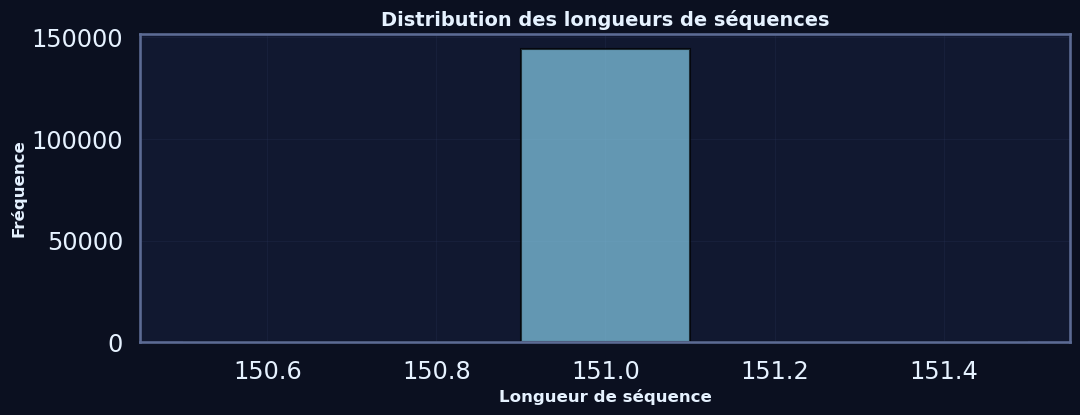

In [86]:
# Longueurs des séquences (elles sont toutes fixes = SEQ_LEN + 1)
sequence_lengths = [len(seq) for seq in sequences]

print("\nDimensions des données :")
print(f"  X (input)  : {X.shape}  --> (nb_sequences, SEQ_LEN)")
print(f"  y (output) : {y.shape}  --> (nb_sequences,)")

print("\nLongueur maximale théorique d'une séquence :", max(sequence_lengths))
print("Longueur minimale théorique d'une séquence :", min(sequence_lengths))

# Comme nos séquences sont toutes fixes (SEQ_LEN+1), on vérifie la distribution
plt.figure(figsize=(12, 4))
plt.hist(sequence_lengths, bins=5, edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Longueur de séquence', fontsize=12, fontweight='bold')
plt.ylabel('Fréquence', fontsize=12, fontweight='bold')
plt.title('Distribution des longueurs de séquences', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.show()

### Construction du dataset séquentiel


In [87]:
# Conversion vers torch.Tensor
X_tensor = torch.tensor(X, dtype=torch.long)
y_tensor = torch.tensor(y, dtype=torch.long)

# Calcul des tailles
dataset_size = len(X_tensor)
val_size = int(dataset_size * 0.1)
train_size = dataset_size - val_size

# Split aléatoire reproductible
generator = torch.Generator().manual_seed(SEED_GLOBAL)

train_dataset, val_dataset = torch.utils.data.random_split(
    list(zip(X_tensor, y_tensor)),
    lengths=[train_size, val_size],
    generator=generator
)

print("Split effectué - PyTorch")
print("  - train dataset :", len(train_dataset))
print("  - val dataset   :", len(val_dataset))

Split effectué - PyTorch
  - train dataset : 129997
  - val dataset   : 14444


## Modèle Baseline : LSTM (Approche traditionnelle)


In [88]:
class LSTMModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=100,
        lstm_units=128,
        num_layers=2,
        dropout=0.2,
    ):
        super().__init__()

        # Embedding : (batch, seq_len) → (batch, seq_len, embedding_dim)
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim
        )

        # LSTM empilé
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=lstm_units,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Couche linéaire : (batch, lstm_units) → (batch, vocab_size)
        self.fc = nn.Linear(lstm_units, vocab_size)

    def forward(self, x):
        # x : (batch, seq_len)
        x = self.embedding(x)             # (batch, seq_len, emb)
        out, _ = self.lstm(x)             # (batch, seq_len, lstm_units)
        out = out[:, -1, :]               # garder le dernier état
        logits = self.fc(out)             # (batch, vocab_size)
        return logits


def create_lstm_model(
    vocab_size,
    embedding_dim=100,
    lstm_units=128,
    num_layers=2,
    dropout=0.2,
):
    """Crée un modèle LSTM PyTorch pour la génération de texte."""
    model = LSTMModel(
        vocab_size=vocab_size,
        embedding_dim=embedding_dim,
        lstm_units=lstm_units,
        num_layers=num_layers,
        dropout=dropout,
    )
    return model

In [89]:
create_lstm_model

<function __main__.create_lstm_model(vocab_size, embedding_dim=100, lstm_units=128, num_layers=2, dropout=0.2)>

### Création du modèle


In [90]:
# Création du modèle PyTorch
lstm_model = create_lstm_model(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    lstm_units=LSTM_UNITS,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(device)

print("\nModèle LSTM créé !")
print(lstm_model)

# Compteur de paramètres
total_params = sum(p.numel() for p in lstm_model.parameters())
trainable_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)

print(f"\nParamètres totaux        : {total_params:,}")
print(f"Paramètres entraînables  : {trainable_params:,}")

# Définition de l’optimizer et de la loss
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)

print("\nOptimiseur et fonction de perte configurés (Adam + CrossEntropyLoss).")


Modèle LSTM créé !
LSTMModel(
  (embedding): Embedding(11080, 32)
  (lstm): LSTM(32, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=11080, bias=True)
)

Paramètres totaux        : 1,998,920
Paramètres entraînables  : 1,998,920

Optimiseur et fonction de perte configurés (Adam + CrossEntropyLoss).


### Callbacks

#### Callbacks d’early stopping pour éviter l’overfitting


In [91]:
class EarlyStopping:
    """Early stopping maison pour PyTorch, avec sauvegarde du meilleur modèle."""
    def __init__(self, patience=50, verbose=True):
        self.patience = patience
        self.verbose = verbose
        self.best_loss = float('inf')
        self.counter = 0
        self.best_state_dict = None

    def step(self, val_loss, model):
        """Retourne True si on doit arrêter l'entraînement."""
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            # Sauvegarde des meilleurs poids
            self.best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            if self.verbose:
                print(f"Nouvelle meilleure val_loss: {val_loss:.4f} — sauvegarde des poids")
            return False
        else:
            self.counter += 1
            if self.verbose:
                print(f"Pas d'amélioration ({self.counter}/{self.patience})")
            return self.counter >= self.patience

    def restore_best_weights(self, model):
        """Restaure les meilleurs poids connus."""
        if self.best_state_dict is not None:
            model.load_state_dict(self.best_state_dict)
            if self.verbose:
                print("Meilleurs poids restaurés")

#### Checkpoint pour sauvegarder le meilleur modèle

In [92]:
# === Chemin du checkpoint ===
checkpoint_path = project_root / "models" / f"{OUTPUT_MODEL_NAME}.pt"
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

print(f"Checkpoint path : {checkpoint_path}")

class ModelCheckpoint:
    """Sauvegarde automatique du meilleur modèle (équivalent Keras)."""
    def __init__(self, filepath, verbose=True):
        self.filepath = filepath
        self.best_loss = float('inf')
        self.verbose = verbose

    def step(self, val_loss, model):
        """Sauvegarde si amélioration."""
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.filepath)
            if self.verbose:
                print(f"Amélioration détectée — modèle sauvegardé (val_loss={val_loss:.4f})")

# Initialisation du checkpoint
checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    verbose=True
)

Checkpoint path : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\models\lstm_v5.pt


#### Callback pour visualiser la progression

In [93]:
class TrainingProgressCallback:
    """Callback PyTorch pour suivre et visualiser la progression de l'entraînement."""
    def __init__(self):
        self.train_losses = []
        self.val_losses = []

    def update(self, train_loss, val_loss):
        """Enregistre les valeurs et affiche la progression."""
        self.train_losses.append(train_loss)
        self.val_losses.append(val_loss)

        # Affichage live (clear output Jupyter)
        clear_output(wait=True)

        fig, ax = plt.subplots(1, 1, figsize=(10, 4))

        ax.plot(self.train_losses, label="Train Loss", color="orange", marker="o")
        ax.plot(self.val_losses, label="Val Loss", color="purple", marker="o")
        ax.set_title("Loss (LSTM)", fontsize=14, fontweight="bold")
        ax.set_xlabel("Epoch", fontsize=12)
        ax.set_ylabel("Loss", fontsize=12)
        ax.grid(alpha=0.3)
        ax.legend()

        plt.tight_layout()
        plt.show()

        print(f"Epoch {len(self.train_losses)} — "
              f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")


# Instanciation du callback
progress_callback_lstm = TrainingProgressCallback()

### Entraînement du modèle

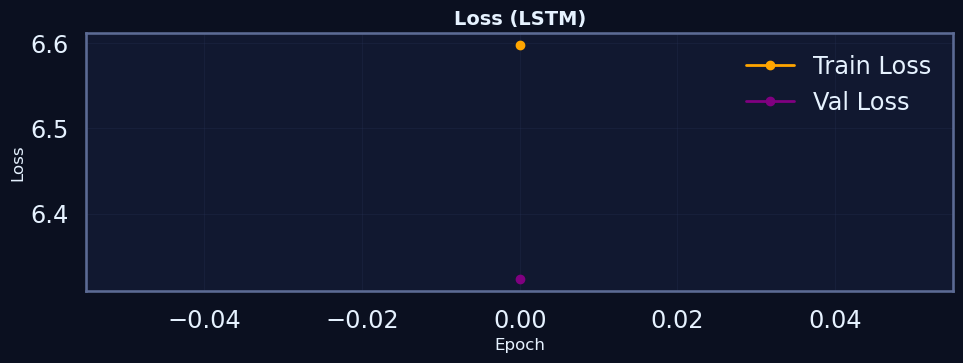

Epoch 1 — train_loss=6.5983 | val_loss=6.3226
Amélioration détectée — modèle sauvegardé (val_loss=6.3226)
Epoch 1/150 — train_loss=6.5983 | val_loss=6.3226


In [ ]:
print("Début de l'entraînement du modèle LSTM (PyTorch)...\n")

# DataLoaders directement à partir des datasets déjà créés
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

# Historique
history_lstm = {
    "train_loss": [],
    "val_loss": []
}

for epoch in range(1, EPOCHS + 1):
    # ===== Entraînement =====
    lstm_model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = lstm_model(X_batch)          # (batch, vocab_size)
        loss = criterion(logits, y_batch)     # CrossEntropyLoss

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = running_train_loss / len(train_dataset)

    # ===== Validation =====
    lstm_model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = lstm_model(X_batch)
            loss = criterion(logits, y_batch)

            running_val_loss += loss.item() * X_batch.size(0)

    epoch_val_loss = running_val_loss / len(val_dataset)

    # Historique & callbacks
    history_lstm["train_loss"].append(epoch_train_loss)
    history_lstm["val_loss"].append(epoch_val_loss)

    # Callback de progression (affichage + graph)
    progress_callback_lstm.update(epoch_train_loss, epoch_val_loss)

    # Checkpoint du meilleur modèle
    checkpoint.step(epoch_val_loss, lstm_model)

    print(f"Epoch {epoch}/{EPOCHS} — "
          f"train_loss={epoch_train_loss:.4f} | val_loss={epoch_val_loss:.4f}")

print("\nEntraînement LSTM PyTorch terminé !")

### Perplexité

In [ ]:
# On récupère la dernière validation loss enregistrée
final_val_loss = history_lstm["val_loss"][-1]

# Calcul de la perplexité
perplexity = np.exp(final_val_loss)

print(f"Perplexité approx : {perplexity:.2f}")

## Test de génération de texte avec LSTM

In [ ]:
def generate_text(
    model,
    seed_text,
    word2idx,
    idx2word,
    num_words=10,
    temperature=1.0,
    seed=None
):
    """
    Génère du texte word-level avec LSTM PyTorch.
    - temperature contrôle la créativité (0.5=conservateur, 1.0=équilibré, >1.5 très créatif).
    """

    # Random state pour la reproductibilité
    rng = np.random.default_rng(seed) if seed is not None else np.random

    model.eval()
    generated = seed_text.lower().strip()

    for _ in range(num_words):

        # Tokenisation seed → indices
        words = generated.split()
        token_ids = [word2idx.get(w, word2idx["<UNK>"]) for w in words]

        # Padding à gauche pour obtenir SEQ_LEN
        if len(token_ids) < SEQ_LEN:
            padded = [word2idx["<PAD>"]] * (SEQ_LEN - len(token_ids)) + token_ids
        else:
            padded = token_ids[-SEQ_LEN:]  # garder les SEQ_LEN derniers mots

        x = torch.tensor([padded], dtype=torch.long, device=device)

        # Prédiction PyTorch
        with torch.no_grad():
            logits = model(x)  # (1, vocab_size)
            logits = logits.squeeze(0).cpu().numpy()

        # Température
        logits = logits.astype(np.float64)
        logits = logits / max(temperature, 1e-8)

        # Softmax manuel (stable)
        exp_logits = np.exp(logits - np.max(logits))
        probs = exp_logits / exp_logits.sum()

        # Échantillonnage multinomial
        next_id = rng.choice(len(probs), p=probs)

        # Convertir id → mot
        next_word = idx2word.get(next_id, "<UNK>")

        # Ajouter au texte
        generated += " " + next_word

    return generated

## Génération de texte : tests qualitatifs

In [ ]:
# Comparaison de génération de texte
print("\n" + "=" * 90)
print(" " * 20 + "COMPARAISON DE GÉNÉRATION DE TEXTE")
print("=" * 90)

test_seeds = [
    "lose fat and gain muscle",
    "3 workout sessions per week",
    "I sprained my right ankle",
    "background in judo and tennis",
    "getting back into training at a gym"
]

for seed in test_seeds:
    print(f"\nSeed: '{seed}'")
    print("-" * 90)

    # LSTM PyTorch
    lstm_gen = generate_text(
        model=lstm_model,
        seed_text=seed,
        word2idx=word2idx,
        idx2word=idx2word,
        num_words=10,
        temperature=0.7
    )

    print(f"> LSTM : {lstm_gen}\n")

## Test avec différentes températures

In [ ]:
# Test avec différentes températures
print("\n" + "=" * 90)
print(" " * 25 + "EFFET DE LA TEMPÉRATURE")
print("=" * 90)

seed_test = "lose fat and gain muscle"
temperatures = [0.5, 1.0, 1.5, 2.0]

print(f"\nSeed: '{seed_test}'\n")

for temp in temperatures:
    print(f"\nTempérature: {temp}")
    print("-" * 90)

    # Générer plusieurs fois pour montrer la variabilité
    for i in range(3):
        gen_text = generate_text(
            model=lstm_model,
            seed_text=seed_test,
            word2idx=word2idx,
            idx2word=idx2word,
            num_words=8,
            temperature=temp,
            seed=SEED_GEN + i
        )
        print(f"  {i+1}. {gen_text}")


## Carnet d’expériences

In [ ]:
# Répertoire des logs
logs_dir = project_root / "logs"
logs_dir.mkdir(parents=True, exist_ok=True)

# Nom du fichier expérimental
timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
experiment_filename = logs_dir / f"experiment_{OUTPUT_MODEL_NAME}_{timestamp}.json"

# Récupération des valeurs finales
final_train_loss = float(history_lstm["train_loss"][-1])
final_val_loss   = float(history_lstm["val_loss"][-1]) if history_lstm["val_loss"] else None

experiment_log = {
    "model_name": OUTPUT_MODEL_NAME,
    "vocab_size": vocab_size,
    "sequence_length": SEQ_LEN,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "final_train_loss": final_train_loss,
    "final_val_loss": final_val_loss,
    "perplexity": float(perplexity),
    "seeds_tested": SEED_GEN,  # liste de seeds utilisée pour les tests
}

print("\nRÉSUMÉ EXPÉRIMENTAL")
for key, value in experiment_log.items():
    print(f"- {key}: {value}")

# Sauvegarde JSON
with open(experiment_filename, "w", encoding="utf-8") as f:
    json.dump(experiment_log, f, indent=4, ensure_ascii=False)

print(f"\nLog expérimental sauvegardé : {experiment_filename}")

## Informations relatives au modèle (son nom et les métriques associées)

In [ ]:
# Répertoire du modèle (même que le checkpoint .pt)
model_dir = checkpoint_path.parent
model_dir.mkdir(parents=True, exist_ok=True)

# Fichier de rapport LSTM
report_path = model_dir / "LSTM_model_report.json"

# Sécurité : récupération des métriques finales
final_train_loss = float(history_lstm["train_loss"][-1])
final_val_loss   = float(history_lstm["val_loss"][-1]) if history_lstm["val_loss"] else None
best_val_loss    = float(min(history_lstm["val_loss"])) if history_lstm["val_loss"] else None

# Contexte d'évaluation du modèle LSTM
lstm_report = {
    "created_at": datetime.utcnow().isoformat() + "Z",
    "task": "language_modeling_next_word",
    "target": "next_token_prediction",
    "n_train_samples": int(len(train_dataset)) if "train_dataset" in globals() else None,
    "n_val_samples": int(len(val_dataset)) if "val_dataset" in globals() else None,
    "vocab_size": int(vocab_size),
    "sequence_length": int(SEQ_LEN),
    "device": str(device),
    "model": {
        "name": OUTPUT_MODEL_NAME,
        "type": "LSTM",
        "class": lstm_model.__class__.__name__,
        "model_path": str(checkpoint_path.resolve()),
        "embedding_dim": int(EMBEDDING_DIM),
        "lstm_units": int(LSTM_UNITS),
        "num_layers": int(NUM_LAYERS),
        "dropout": float(DROPOUT),
    },
    "training": {
        "epochs": int(EPOCHS),
        "batch_size": int(BATCH_SIZE),
        "optimizer": type(optimizer).__name__,
        "loss_fn": type(criterion).__name__,
        "seed_global": int(SEED_GLOBAL),
    },
    "metrics": {
        "final_train_loss": final_train_loss,
        "final_val_loss": final_val_loss,
        "best_val_loss": best_val_loss,
        "perplexity": float(perplexity),
    }
}

print("\nLSTM MODEL REPORT")
for section, value in lstm_report.items():
    if isinstance(value, dict):
        print(f"- {section}:")
        for k, v in value.items():
            print(f"    • {k}: {v}")
    else:
        print(f"- {section}: {value}")

with open(report_path, "w", encoding="utf-8") as f:
    json.dump(lstm_report, f, ensure_ascii=False, indent=2)

print(f"\nRapport LSTM JSON enregistré : {report_path}")
